In [ ]:
import zipfile
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.model_selection import train_test_split
from torchsummary import summary
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import time
from tqdm import tqdm
from PIL import Image
from glob import glob
import random
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import warnings
warnings.filterwarnings("ignore")
from torchsummary import summary

In [ ]:
zip_path = "/content/cnn_dataset.zip"
extract_path = "/content/cnn_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extracted files:", os.listdir(extract_path))

Extracted files: ['vehicles', 'food', 'dogs']


In [ ]:
def load_dataset(data_path):
    classes = ['dogs', 'food', 'vehicles']
    images = []
    labels = []

    for idx, class_name in enumerate(classes):
        class_path = f"{data_path}/{class_name}/*.jpg"
        class_images = glob(class_path)
        for img_path in class_images:
            img = Image.open(img_path).resize((64, 64))
            img = np.array(img)
            images.append(img)
            labels.append(idx)

    images = np.array(images)
    labels = np.array(labels)
    return images, labels


data_path = "cnn_dataset"
images, labels = load_dataset(data_path)
print(f"Total images: {len(images)}")
print(f"Image shape: {images[0].shape}")
print(f"Number of classes: {len(np.unique(labels))}")
print(f"Class distribution: {np.bincount(labels)}")

class_names = ['dogs', 'food', 'vehicles']

Total images: 30000
Image shape: (64, 64, 3)
Number of classes: 3
Class distribution: [10000 10000 10000]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


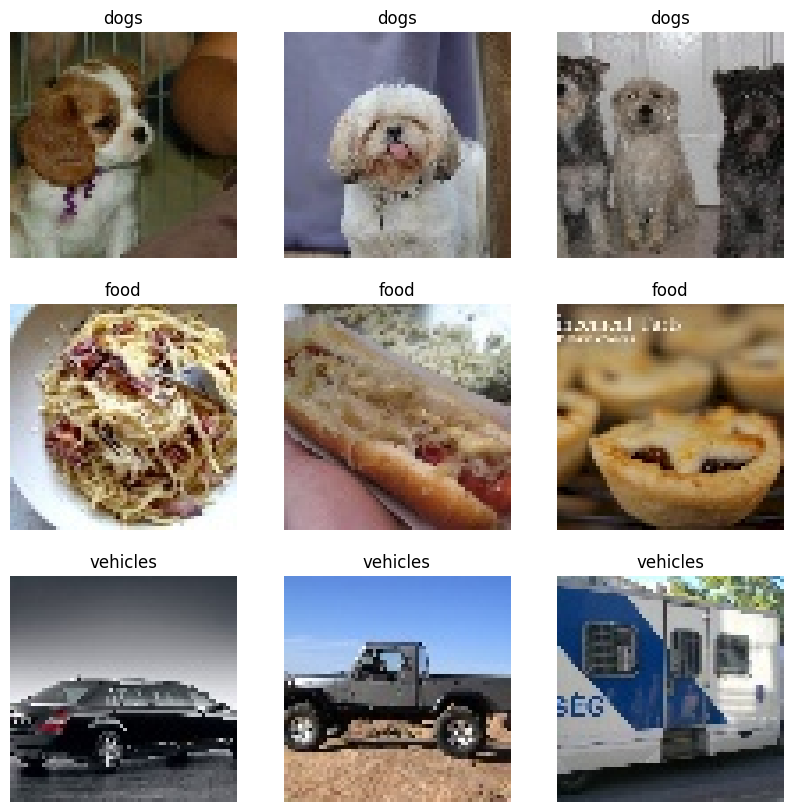

In [ ]:
def plot_sample_images(images, labels, class_names, n_samples=3):
    plt.figure(figsize=(10, 10))
    for class_idx, class_name in enumerate(class_names):
        class_images = images[labels == class_idx]
        for i in range(n_samples):
            plt.subplot(len(class_names), n_samples, class_idx * n_samples + i + 1)
            plt.imshow(class_images[i])
            plt.title(class_name)
            plt.axis('off')
    plt.show()

class_names = ['dogs', 'food', 'vehicles']
plot_sample_images(images, labels, class_names)

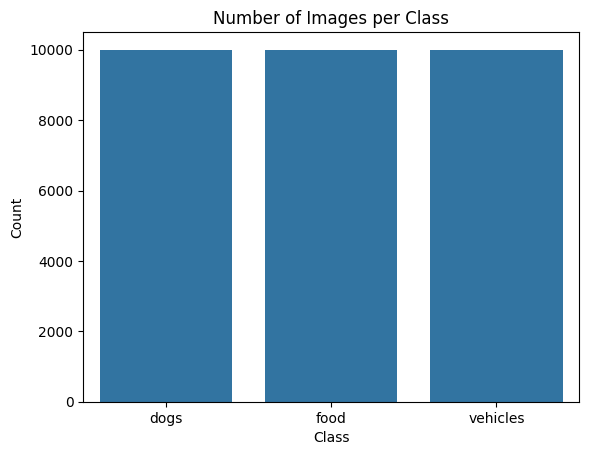

In [ ]:
def plot_class_distribution(labels, class_names):
    sns.countplot(x=labels)
    plt.xticks(ticks=np.arange(len(class_names)), labels=class_names)
    plt.title('Number of Images per Class')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()

plot_class_distribution(labels, class_names)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print(f"Training set: {X_train.shape[0]} images")
print(f"Validation set: {X_val.shape[0]} images")
print(f"Testing set: {X_test.shape[0]} images")

Training set: 21000 images
Validation set: 4500 images
Testing set: 4500 images


In [ ]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

class CustomImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

train_dataset = CustomImageDataset(X_train, y_train, transform=transform)
val_dataset = CustomImageDataset(X_val, y_val, transform=transform)
test_dataset = CustomImageDataset(X_test, y_test, transform=transform)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, worker_init_fn=seed_worker)
val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=4, pin_memory=True)

In [ ]:
class ResNeXtBlock(nn.Module):
    def __init__(self, in_channels, out_channels, cardinality=32, stride=1):
        super(ResNeXtBlock, self).__init__()
        bottleneck_channels = out_channels // 2

        self.conv1x1_reduce = nn.Conv2d(in_channels, bottleneck_channels, kernel_size=1, bias=False)
        self.batch_norm1 = nn.BatchNorm2d(bottleneck_channels)

        self.conv3x3_grouped = nn.Conv2d(bottleneck_channels, bottleneck_channels, kernel_size=3, stride=stride, padding=1, groups=cardinality, bias=False)
        self.batch_norm2 = nn.BatchNorm2d(bottleneck_channels)

        self.conv1x1_expand = nn.Conv2d(bottleneck_channels, out_channels, kernel_size=1, bias=False)
        self.batch_norm3 = nn.BatchNorm2d(out_channels)

        self.activation = nn.ReLU(inplace=True)

        self.skip_connection = None
        if stride != 1 or in_channels != out_channels:
            self.skip_connection = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x
        if self.skip_connection is not None:
            identity = self.skip_connection(x)

        output = self.conv1x1_reduce(x)
        output = self.batch_norm1(output)
        output = self.activation(output)

        output = self.conv3x3_grouped(output)
        output = self.batch_norm2(output)
        output = self.activation(output)

        output = self.conv1x1_expand(output)
        output = self.batch_norm3(output)

        output += identity
        output = self.activation(output)

        return output


class ResNeXt(nn.Module):
    def __init__(self, num_classes=3):
        super(ResNeXt, self).__init__()
        self.initial_conv = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.batch_norm = nn.BatchNorm2d(64)
        self.activation = nn.ReLU(inplace=True)
        self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 128, num_blocks=3)
        self.layer2 = self._make_layer(128, 256, num_blocks=4, stride=2)
        self.layer3 = self._make_layer(256, 512, num_blocks=6, stride=2)
        self.layer4 = self._make_layer(512, 1024, num_blocks=3, stride=2)

        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fully_connected = nn.Linear(1024, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride=1):
        layers = [ResNeXtBlock(in_channels, out_channels, stride=stride)]
        for _ in range(1, num_blocks):
            layers.append(ResNeXtBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.initial_conv(x)
        x = self.batch_norm(x)
        x = self.activation(x)
        x = self.max_pool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.fully_connected(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNeXt(num_classes=3).to(device)
summary(model, (3, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           9,408
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
         MaxPool2d-4           [-1, 64, 16, 16]               0
            Conv2d-5          [-1, 128, 16, 16]           8,192
       BatchNorm2d-6          [-1, 128, 16, 16]             256
            Conv2d-7           [-1, 64, 16, 16]           4,096
       BatchNorm2d-8           [-1, 64, 16, 16]             128
              ReLU-9           [-1, 64, 16, 16]               0
           Conv2d-10           [-1, 64, 16, 16]           1,152
      BatchNorm2d-11           [-1, 64, 16, 16]             128
             ReLU-12           [-1, 64, 16, 16]               0
           Conv2d-13          [-1, 128, 16, 16]           8,192
      BatchNorm2d-14          [-1, 128,

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, val_loader, num_epochs=10):
    training_losses, validation_losses = [], []
    training_accuracies, validation_accuracies = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_predictions, total_samples = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted_labels = torch.max(outputs, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted_labels == labels).sum().item()
        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct_predictions / total_samples
        training_losses.append(train_loss)
        training_accuracies.append(train_accuracy)
        val_loss, val_accuracy = evaluate_accuracy(model, val_loader)
        validation_losses.append(val_loss)
        validation_accuracies.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")

    return training_losses, validation_losses, training_accuracies, validation_accuracies

def evaluate_accuracy(model, data_loader):
    model.eval()
    total_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, predicted_labels = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted_labels == labels).sum().item()

    avg_val_loss = total_loss / len(data_loader)
    val_accuracy = 100 * correct / total
    return avg_val_loss, val_accuracy

train_losses, val_losses, train_accs, val_accs = train_model(model, train_loader, val_loader)


Epoch [1/10] | Train Loss: 0.5752 | Train Acc: 76.52% | Val Loss: 0.4471 | Val Acc: 83.53%
Epoch [2/10] | Train Loss: 0.3583 | Train Acc: 86.16% | Val Loss: 0.4093 | Val Acc: 85.11%
Epoch [3/10] | Train Loss: 0.3001 | Train Acc: 88.65% | Val Loss: 0.3143 | Val Acc: 87.69%
Epoch [4/10] | Train Loss: 0.2615 | Train Acc: 90.28% | Val Loss: 0.3207 | Val Acc: 89.24%
Epoch [5/10] | Train Loss: 0.2281 | Train Acc: 91.24% | Val Loss: 0.3594 | Val Acc: 88.33%
Epoch [6/10] | Train Loss: 0.2040 | Train Acc: 92.33% | Val Loss: 0.3125 | Val Acc: 89.93%
Epoch [7/10] | Train Loss: 0.2004 | Train Acc: 92.72% | Val Loss: 0.2772 | Val Acc: 90.16%
Epoch [8/10] | Train Loss: 0.1767 | Train Acc: 93.40% | Val Loss: 0.3358 | Val Acc: 88.44%
Epoch [9/10] | Train Loss: 0.2644 | Train Acc: 91.15% | Val Loss: 0.3698 | Val Acc: 86.58%
Epoch [10/10] | Train Loss: 0.2119 | Train Acc: 92.34% | Val Loss: 0.2676 | Val Acc: 90.40%


In [ ]:
def test_model(model, test_loader):
    model.eval()
    test_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    all_predictions = []
    all_true_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted_labels = torch.max(outputs, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted_labels == labels).sum().item()

            all_predictions.extend(predicted_labels.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())

    test_loss /= len(test_loader)
    test_accuracy = 100 * correct_predictions / total_samples

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.2f}%")
    return test_loss, test_accuracy, all_predictions, all_true_labels

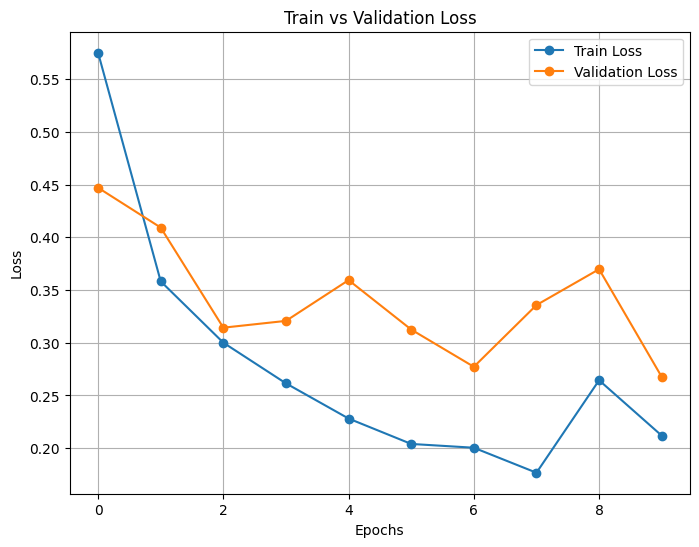

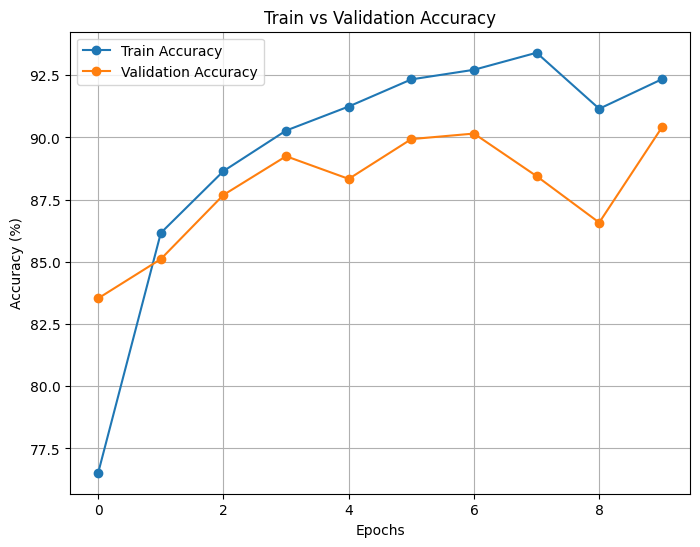

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(train_accs, label='Train Accuracy', marker='o')
plt.plot(val_accs, label='Validation Accuracy', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


Test Loss: 0.2443
Test Accuracy: 90.64%


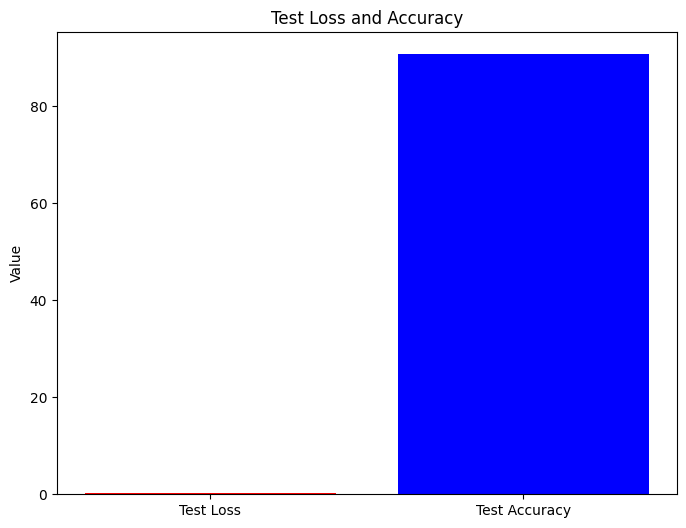

In [ ]:
test_loss, test_accuracy, all_preds, all_labels = test_model(model, test_loader)
plt.figure(figsize=(8, 6))
plt.bar(["Test Loss", "Test Accuracy"], [test_loss, test_accuracy], color=['red', 'blue'])
plt.title("Test Loss and Accuracy")
plt.ylabel("Value")
plt.show()

In [ ]:
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

        dogs       0.90      0.89      0.89      1539
        food       0.92      0.88      0.90      1465
    vehicles       0.90      0.95      0.93      1496

    accuracy                           0.91      4500
   macro avg       0.91      0.91      0.91      4500
weighted avg       0.91      0.91      0.91      4500



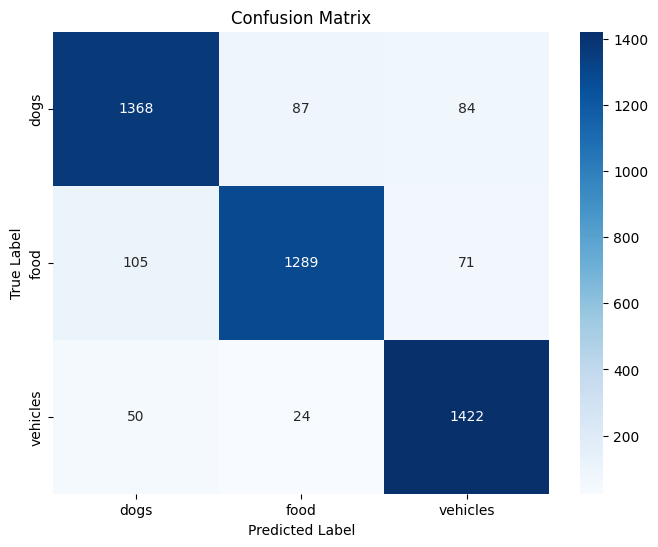

In [ ]:
conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

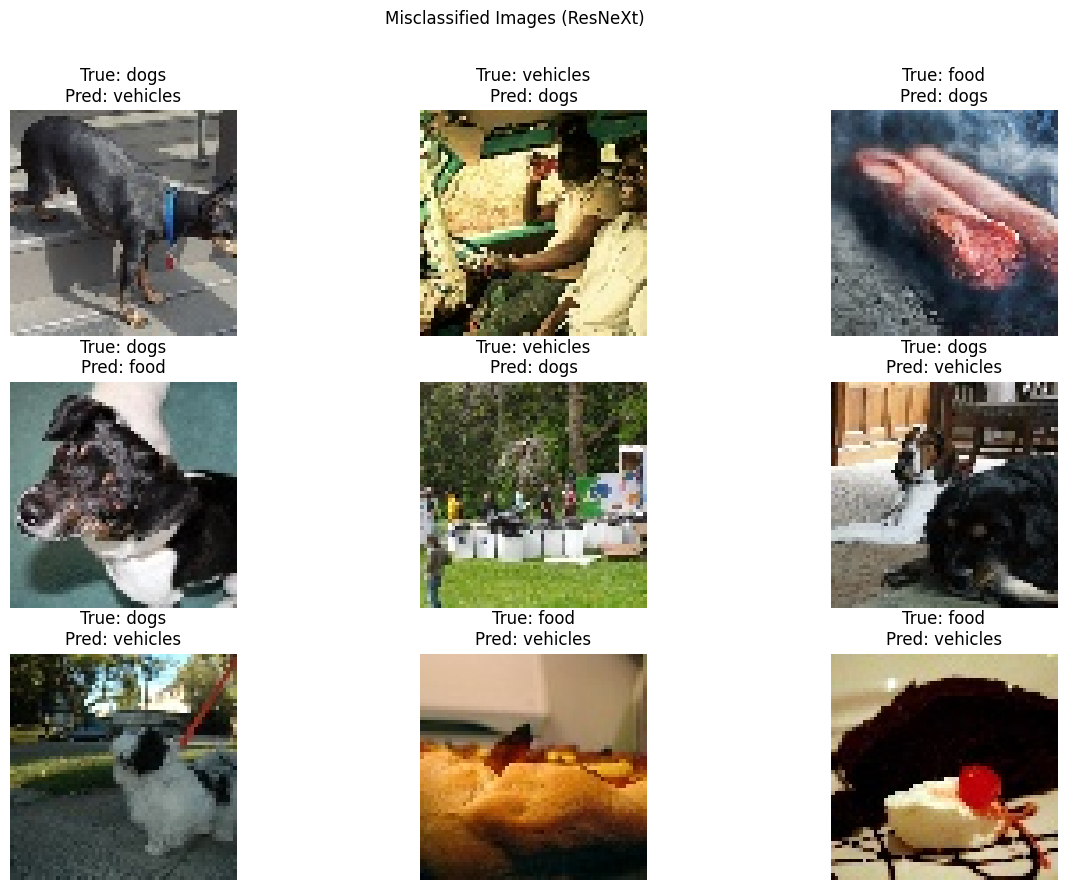

In [ ]:
misclassified_indices = np.where(np.array(all_preds) != np.array(all_labels))[0]
plt.figure(figsize=(15, 10))
for i, idx in enumerate(misclassified_indices[:9]):
    plt.subplot(3, 3, i + 1)
    img = X_test[idx]
    true_label = class_names[all_labels[idx]]
    pred_label = class_names[all_preds[idx]]
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")
plt.suptitle("Misclassified Images (ResNeXt)")
plt.show()

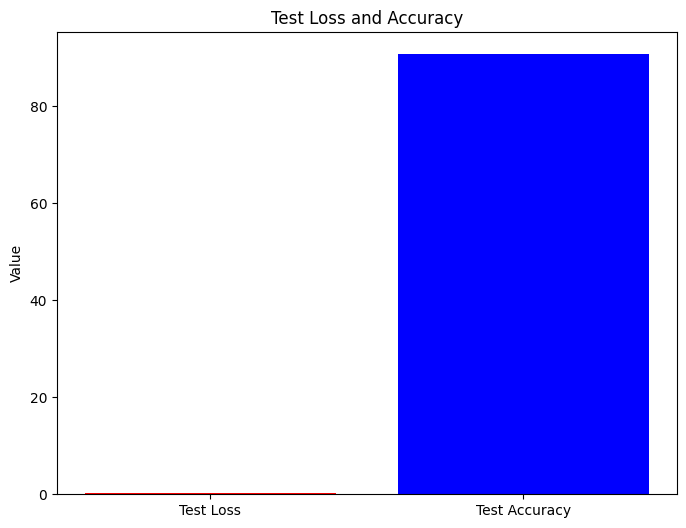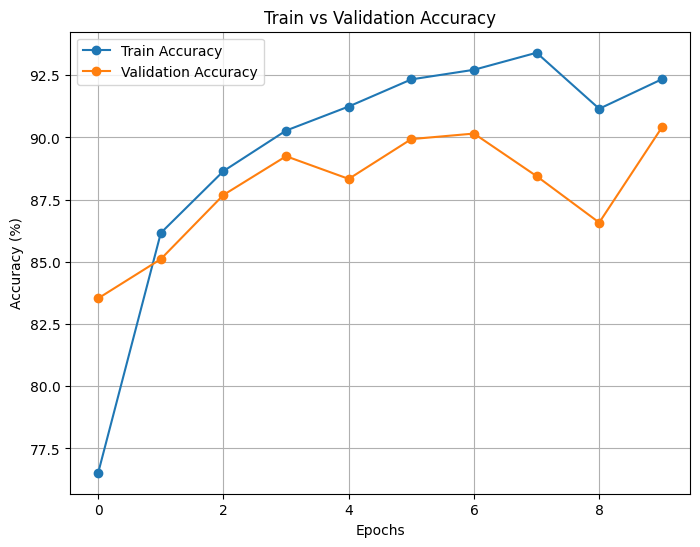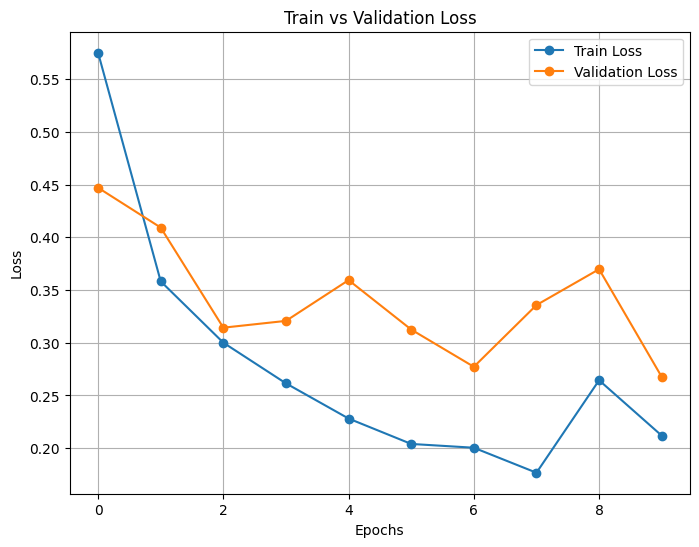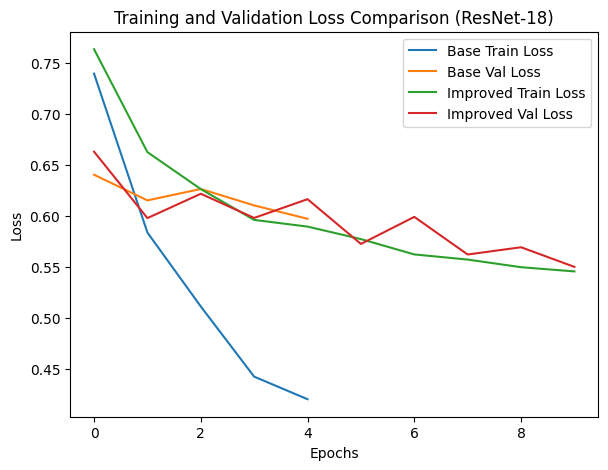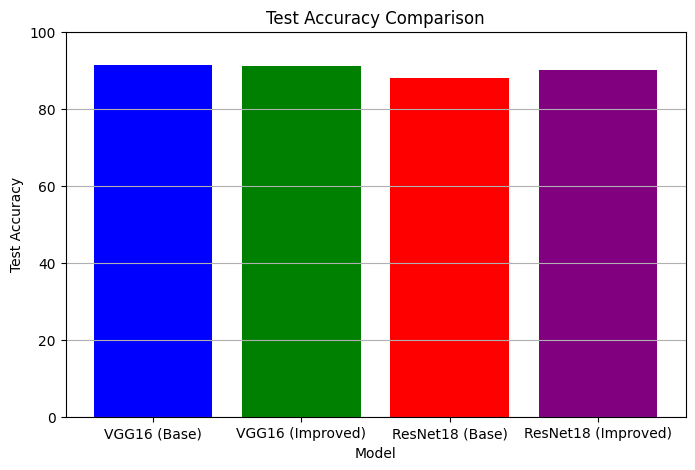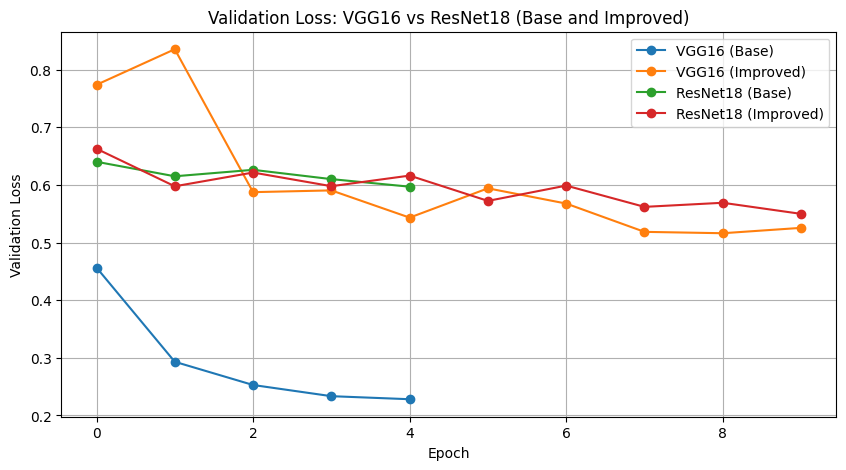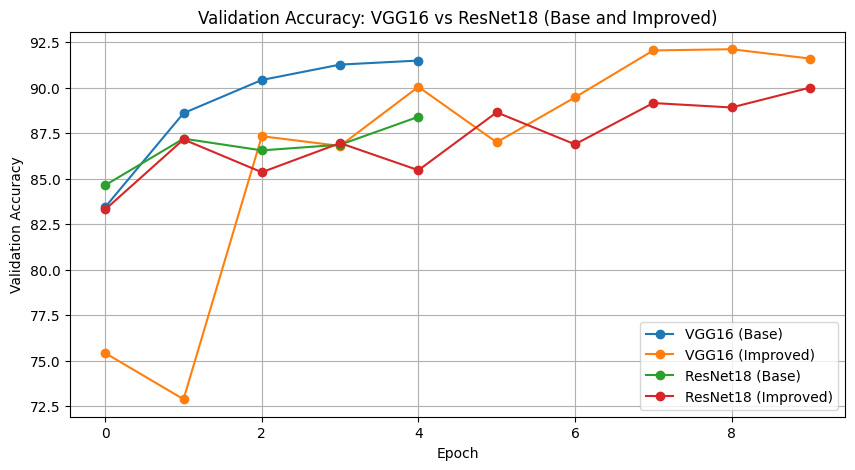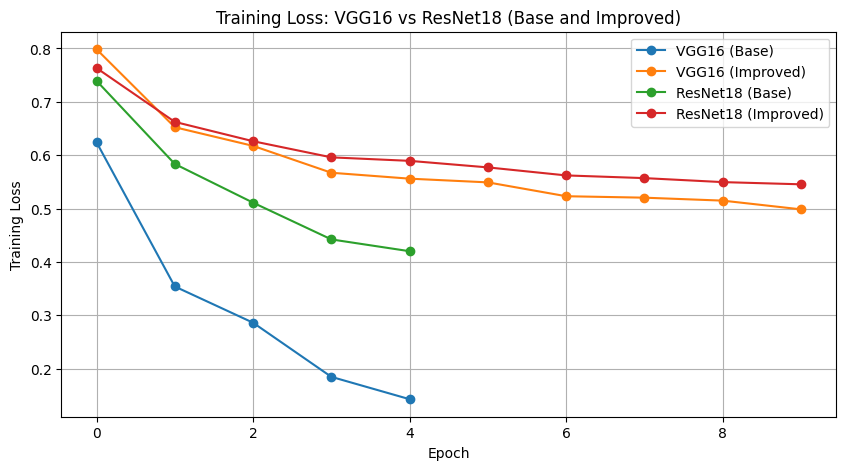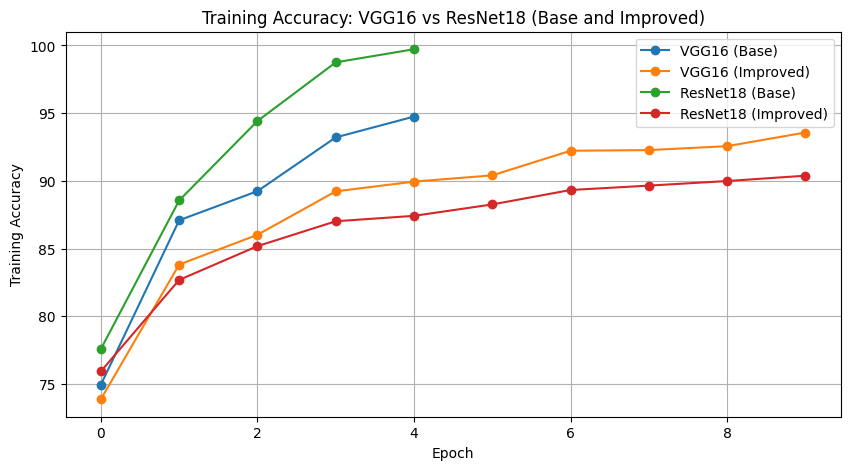



- VGG16 (Base): 91% accuracy, 91% precision, 91% recall, 91% F1-score
- VGG16 (Improved): 91% accuracy, 92% precision, 91% recall, 91% F1-score
- ResNet18 (Base): 88% accuracy, 88% precision, 88% recall, 88% F1-score
- ResNet18 (Improved): 90% accuracy, 90% precision, 90% recall, 90% F1-score
- ResNext: 91% accuracy, 91% precision, 91% recall, 91% F1-score

ResNeXt outperforms ResNet primarily due to the introduction of cardinality and grouped convolutions, which make the model more efficient at learning from complex data without increasing the number of parameters excessively. By utilizing residual connections and bottleneck designs, ResNeXt maintains a similar architecture to ResNet but with significant improvements in terms of feature extraction and computational efficiency. These factors combined make ResNeXt a stronger model, especially when applied to deep learning tasks requiring high performance with less computational cost.


**References**
1. Based on ased on the CSE 676 Deep Learning Assignment 1 Part I and II by Satwika Davala, Mythri Shivakumar
2. https://paperswithcode.com/method/resnext
3. https://pytorch.org/vision/main/models/resnext.html
4. https://numpy.org
5. https://pandas.pydata.org
6. https://matplotlib.org